In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading model...
Running GPU predictions 🚀 ...

✅ Test Accuracy: 97.62%

Classification Report:
                  precision    recall  f1-score   support

     Anthracnose       0.97      0.93      0.95       100
Bacterial Canker       1.00      0.99      0.99       100
  Cutting Weevil       1.00      1.00      1.00       100
        Die Back       1.00      0.98      0.99       100
      Gall Midge       0.96      0.99      0.98       100
         Healthy       0.99      1.00      1.00       100
  Powdery Mildew       0.93      1.00      0.96       100
     Sooty Mould       0.97      0.92      0.94       100

        accuracy                           0.98       800
       macro avg       0.98      0.98      0.98       800
    weighted avg       0.98      0.98      0.98       800



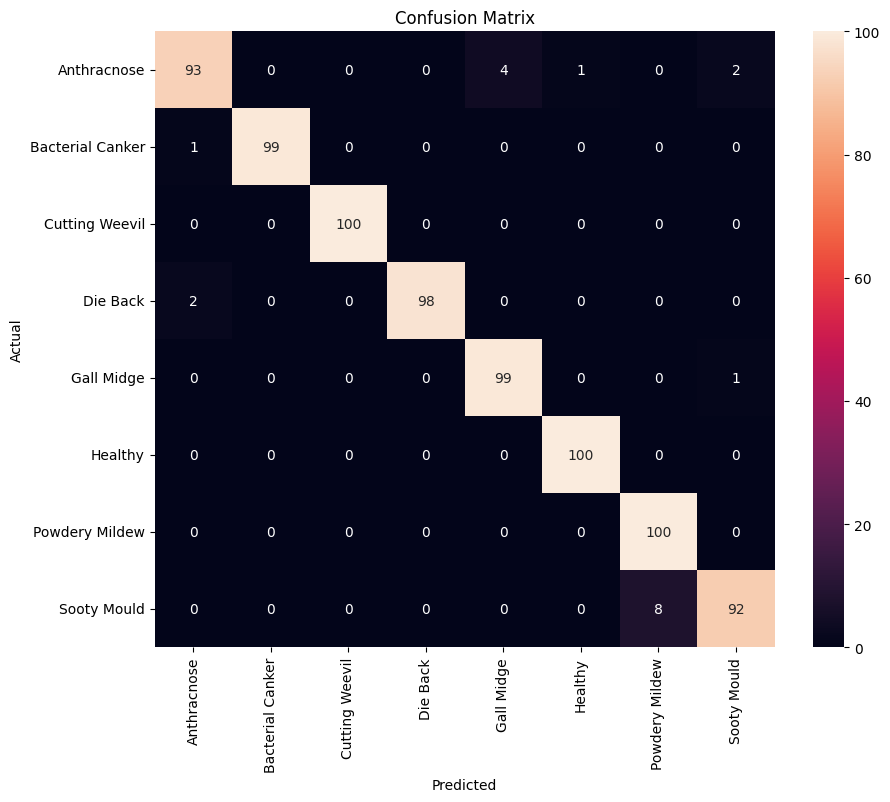

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --------------------------------------------------
# Confirm GPU
# --------------------------------------------------
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# --------------------------------------------------
# PATHS
# --------------------------------------------------
MODEL_PATH = "/content/drive/MyDrive/Datasets/mango/model_mango_disease.keras"
TEST_DIR = "/content/drive/MyDrive/Datasets/mango/test"

# --------------------------------------------------
# CLASS NAMES
# --------------------------------------------------
CLASS_NAMES = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midge",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould"
]

CLASS_NAMES.sort()

# --------------------------------------------------
# LOAD MODEL (Auto uses GPU)
# --------------------------------------------------
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

IMG_SIZE = 224


def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.efficientnet.preprocess_input(img)

    preds = model.predict(img, verbose=0)
    return np.argmax(preds)


# --------------------------------------------------
# RUN TEST
# --------------------------------------------------
y_true = []
y_pred = []

print("Running GPU predictions 🚀 ...")

for class_index, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(TEST_DIR, class_name)

    for img_name in os.listdir(class_path):

        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):

            img_path = os.path.join(class_path, img_name)

            pred = predict_image(img_path)

            y_true.append(class_index)
            y_pred.append(pred)


# --------------------------------------------------
# METRICS
# --------------------------------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/Datasets/mango/confusion_matrix.png")

plt.show()
